<a href="https://colab.research.google.com/github/dantae74/aice/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tabular 분석
## Brain stroke prediction dataset 분석: 뇌졸증 경험 여부 예측


In [1]:
# 라이브러리 임포트
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
# 딥러닝 라이브러리 임포트
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, Flatten
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/suku-7/AICE-Pro-share/refs/heads/main/brain_stroke_data_training.csv')
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


In [5]:
# Tabular 데이터 전처리 - 라벨 인코딩
df['gender'] = np.where(df['gender']=='Male', 1, 0)
df['ever_married'] = np.where(df['ever_married']=='Yes', 1, 0)

In [6]:
# 결측치 확인
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [7]:
# 전처리 - 원핫 인코딩, object인 데이터 분류
obj_col = df.select_dtypes('object').columns
obj_col

Index(['work_type', 'Residence_type', 'smoking_status'], dtype='object')

In [8]:
# 전처리 - 원핫 인코딩인코딩
df = pd.get_dummies(data=df, columns=obj_col, drop_first=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,228.69,36.6,1,True,False,False,True,True,False,False
1,1,80.0,0,1,1,105.92,32.5,1,True,False,False,False,False,True,False
2,0,49.0,0,0,1,171.23,34.4,1,True,False,False,True,False,False,True
3,0,79.0,1,0,1,174.12,24.0,1,False,True,False,False,False,True,False
4,1,81.0,0,0,1,186.21,29.0,1,True,False,False,True,True,False,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          4981 non-null   int64  
 1   age                             4981 non-null   float64
 2   hypertension                    4981 non-null   int64  
 3   heart_disease                   4981 non-null   int64  
 4   ever_married                    4981 non-null   int64  
 5   avg_glucose_level               4981 non-null   float64
 6   bmi                             4981 non-null   float64
 7   stroke                          4981 non-null   int64  
 8   work_type_Private               4981 non-null   bool   
 9   work_type_Self-employed         4981 non-null   bool   
 10  work_type_children              4981 non-null   bool   
 11  Residence_type_Urban            4981 non-null   bool   
 12  smoking_status_formerly smoked  49

In [10]:
# Tabular 데이터 features, label 분류
features = df.drop('stroke', axis=1)
label = df['stroke']

In [11]:
features.shape, label.shape

((4981, 14), (4981,))

In [12]:
label.value_counts()

,count
stroke,
0,4733
1,248


In [13]:
# Tabular 데이터 Train, valid 데이터셋 분할
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(features, label, test_size=0.3, random_state=42, stratify=label)
x_train.shape, x_val.shape, y_train.shape, y_val.shape

((3486, 14), (1495, 14), (3486,), (1495,))

In [14]:
# LogisticRegression 머신러닝
from sklearn.linear_model import LogisticRegression

lgr = LogisticRegression()
lgr.fit(x_train, y_train)
lgr.score(x_val, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9505016722408027

In [15]:
# SGDClassifier 머신러닝
from sklearn.linear_model import SGDClassifier

sgdc = SGDClassifier()
sgdc.fit(x_train, y_train)
sgdc.score(x_val, y_val)


0.9505016722408027

In [16]:
# DecisionTreeClassifier 머신러닝
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)
dtc.score(x_val, y_val)

0.9016722408026756

In [17]:
# RandomForestClassifier 머신러닝
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
rfc.score(x_val, y_val)

0.9491638795986622

In [18]:
# 딥러닝 모델
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid')) # 2개 분류: sigmoid, 여러개 분류: softmax
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,353 (48.25 KB)

 Non-trainable params: 64 (256.00 B)

In [19]:
# 딥러닝 모델 Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
# Early Stopping 설정: val_loss가 10 에포크 동안 개선되지 않으면 학습 중단
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

In [21]:
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, batch_size=32, callbacks=[es, mc])

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5702 - loss: 0.7378
Epoch 1: val_loss improved from None to 0.32909, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6552 - loss: 0.6472 - val_accuracy: 0.9505 - val_loss: 0.3291
Epoch 2/100
 97/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8474 - loss: 0.4408
Epoch 2: val_loss improved from 0.32909 to 0.28625, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8692 - loss: 0.4053 - val_accuracy: 0.9505 - val_loss: 0.2863
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9189 - loss: 0.2954
Epoch 3: val_loss improved from 0.28625 to 0.20159, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9280 - loss: 0.2777 - val_accuracy: 0.95

In [22]:
# Test 데이터셋 csv 읽기
df_test_org = pd.read_csv('https://raw.githubusercontent.com/suku-7/AICE-Pro-share/refs/heads/main/brain_stroke_data_validation.csv')
df_test = df_test_org.copy()
df_test

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...
196,Male,41.0,0,0,No,Private,Rural,70.15,29.756631,formerly smoked,0
197,Male,40.0,0,0,Yes,Private,Urban,191.15,31.124172,smokes,0
198,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.798304,smokes,0
199,Male,40.0,0,0,Yes,Private,Rural,83.94,29.951301,smokes,0


In [23]:
# Tabular 데이터 전처리 - 라벨 인코딩
df_test['gender'] = np.where(df_test['gender']=='Male', 1, 0)
df_test['ever_married'] = np.where(df_test['ever_married']=='Yes', 1, 0)
df_test.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [24]:
# Test 데이터 전처리 - 원핫 인코딩
obj_col = df_test.select_dtypes('object').columns
df_test = pd.get_dummies(data=df_test, columns=obj_col, drop_first=True)
df_test.head()

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,61.0,0,0,1,202.21,31.555602,1,False,True,False,False,False,True,False
1,0,59.0,0,0,1,76.15,30.242937,1,True,False,False,False,False,False,False
2,1,78.0,0,1,1,219.84,30.698951,1,True,False,False,True,False,False,False
3,1,57.0,0,1,0,217.08,33.808410,1,False,False,False,True,False,False,False
4,1,58.0,0,0,1,189.84,31.378534,1,True,False,False,False,False,False,False


In [25]:
# Test 데이터 features, label 분류
x_test = df_test.drop('stroke', axis=1)
y_test = df_test['stroke']
x_test.shape, y_test.shape

((201, 14), (201,))

In [26]:
# Test 데이터로 머신러닝, 딥러닝 모델 성능 측정
lgr_y_pred = lgr.predict(x_test)
sgdc_y_pred = sgdc.predict(x_test)
dtc_y_pred = dtc.predict(x_test)
rfc_y_pred = rfc.predict(x_test)


# Convert deep learning model probabilities to binary predictions
# The model's output layer is now 'sigmoid', so model_y_pred contains probabilities.
model_y_pred = model.predict(x_test)
model_y_pred_binary = (model_y_pred > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step



- 시험에서는 TestDataset에 대한 라벨이 부여되지 않아 아래와 같이 확인이 가능하지 않습니다.
- 현재 테스트 데이터셋은 라벨도 있고, 모델 성능이 비슷해보여서 비교하는 과정을 가졌습니다.

- 랜덤 포레스트 분류기 성능 (Random Forest Classifier), 결정 트리 분류기 성능 (Decision Tree Classifier)의 성능이 좋음

In [27]:




from sklearn.metrics import accuracy_score, classification_report


print("=== Logistic Regression Performance ===")
print(f"Accuracy: {accuracy_score(y_test, lgr_y_pred):.4f}")
print(classification_report(y_test, lgr_y_pred))

print("\n=== SGDClassifier Performance ===")
print(f"Accuracy: {accuracy_score(y_test, sgdc_y_pred):.4f}")
print(classification_report(y_test, sgdc_y_pred))

print("\n=== Decision Tree Classifier Performance ===")
print(f"Accuracy: {accuracy_score(y_test, dtc_y_pred):.4f}")
print(classification_report(y_test, dtc_y_pred))

print("\n=== Random Forest Classifier Performance ===")
print(f"Accuracy: {accuracy_score(y_test, rfc_y_pred):.4f}")
print(classification_report(y_test, rfc_y_pred))

print("\n=== Deep Learning Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, model_y_pred_binary):.4f}")
print(classification_report(y_test, model_y_pred_binary))

=== Logistic Regression Performance ===
Accuracy: 0.8010
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       161
           1       0.00      0.00      0.00        40

    accuracy                           0.80       201
   macro avg       0.40      0.50      0.44       201
weighted avg       0.64      0.80      0.71       201


=== SGDClassifier Performance ===
Accuracy: 0.8010
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       161
           1       0.00      0.00      0.00        40

    accuracy                           0.80       201
   macro avg       0.40      0.50      0.44       201
weighted avg       0.64      0.80      0.71       201


=== Decision Tree Classifier Performance ===
Accuracy: 0.9204
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       161
           1       0.80      0.80      0.80        40

    accura

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [28]:
# RandomForestClassifier의 예측값을 Test 데이터셋 csv에 추가
df_test_org['pred'] = rfc_y_pred
df_test_org

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,pred
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1,0
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1,0
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1,0
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
196,Male,41.0,0,0,No,Private,Rural,70.15,29.756631,formerly smoked,0,0
197,Male,40.0,0,0,Yes,Private,Urban,191.15,31.124172,smokes,0,0
198,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.798304,smokes,0,0
199,Male,40.0,0,0,Yes,Private,Rural,83.94,29.951301,smokes,0,0


In [29]:
# RandomForestClassifier 모델 저장
import joblib

joblib.dump(rfc, '01030101825_1.pkl')


['01030101825_1.pkl']

In [30]:
# 모델 테스트셋 CSV로 저장
df_test_org.to_csv('01030101825_1.csv', index=False, encoding='utf-8')
df_read = pd.read_csv('01030101825_1.csv')
df_read

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,pred
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1,0
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1,0
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1,0
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
196,Male,41.0,0,0,No,Private,Rural,70.15,29.756631,formerly smoked,0,0
197,Male,40.0,0,0,Yes,Private,Urban,191.15,31.124172,smokes,0,0
198,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.798304,smokes,0,0
199,Male,40.0,0,0,Yes,Private,Rural,83.94,29.951301,smokes,0,0


# 2. 텍스트 분석
## Twitter 감정 분석

In [31]:
text_df = pd.read_csv('https://raw.githubusercontent.com/suku-7/AICE-Pro-share/refs/heads/main/twitter_training.csv', header=None)
text_df

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [32]:
text_df[2].value_counts()

,count
2,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


In [33]:
# 전처리 - 감정 분류에 필요없는 필드 제거
text_df = text_df.drop([0, 1], axis=1)
text_df

,2,3
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...
...,...,...
74677,Positive,Just realized that the Windows partition of my...
74678,Positive,Just realized that my Mac window partition is ...
74679,Positive,Just realized the windows partition of my Mac ...
74680,Positive,Just realized between the windows partition of...


In [34]:
# 데이터 전처리 - column 이름 재정의
# text_df = text_df.rename(columns={2:'label', 3:'text'})로도 가능
text_df.columns = ['label', 'text']
text_df

,label,text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...
...,...,...
74677,Positive,Just realized that the Windows partition of my...
74678,Positive,Just realized that my Mac window partition is ...
74679,Positive,Just realized the windows partition of my Mac ...
74680,Positive,Just realized between the windows partition of...


In [35]:
# 데이터 전처리 - 결측치 확인
text_df.isnull().sum()

,0
label,0
text,686


In [36]:
# 데이터 전처리 - 결측치 제거
text_df = text_df.dropna()
text_df.isnull().sum()

,0
label,0
text,0


In [37]:
# Text 데이터 전처리 - 불용어 여부 확인
# '[^a-zA-Z ]' 으로 적으면 소문자, 대문자, 공백 제외 다른 문자나 숫자가 있는지 확인
# '[^가-힣 ]' 으로 적으면 한글, 공백 제외 다른 문자나 숫자가 있는지 확인
# '[^a-zA-Z가-힣 ]' 으로 적으면 영문, 한글, 공백 제외
# [^a-zA-Z가-힣] <- 공백이 없이 만들면 이후 작업에서 띄어쓰기에 필요한 공백을 모두 제거해버려서 문제가 됩니다.
text_df['text'].str.contains('[^a-zA-Z가-힣 ]').sum()

np.int64(65732)

In [38]:
# 데이터 전처리 - 영문, 한글, 공백 이외 제거
text_df = text_df.copy()

# 영문자 제외 모두 ''으로 제거
text_df['text'] = text_df['text'].str.replace('[^a-zA-Z ]', '', regex=True)

# 앞뒤 공백 제거
text_df['text'] = text_df['text'].str.strip()

# 소문자로 변경
text_df['text'] = text_df['text'].str.lower()


text_df['text'].str.contains('[^a-zA-Z가-힣 ]').sum()

np.int64(0)

In [39]:
# Text 중복 확인
text_df.duplicated().sum()

np.int64(6721)

In [40]:
# Text 중복 제거
text_df = text_df.drop_duplicates()
text_df.duplicated().sum()

np.int64(0)

In [41]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67275 entries, 0 to 74681
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   67275 non-null  object
 1   text    67275 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [42]:
# label 종류 확인
text_df['label'].value_counts()

,count
label,
Negative,20529
Positive,18286
Neutral,16580
Irrelevant,11880


In [43]:
# 라벨 인코딩
text_class_to_label = {'Negative':0, 'Positive':1, 'Neutral':2, 'Irrelevant':3}
text_df['label'] = text_df['label'].map(text_class_to_label)
text_df.head()

,label,text
0,1,im getting on borderlands and i will murder yo...
1,1,i am coming to the borders and i will kill you...
2,1,im getting on borderlands and i will kill you all
3,1,im coming on borderlands and i will murder you...
4,1,im getting on borderlands and i will murder y...


In [44]:
# 라벨 인코딩 확인
text_df['label'].value_counts()

,count
label,
0,20529
1,18286
2,16580
3,11880


In [45]:
# 데이터셋 feature, label 분류
text_features = text_df['text']
text_label = text_df['label']

In [46]:
# train셋, val셋 데이터셋 나누기
from sklearn.model_selection import train_test_split

text_x_train, text_x_val, text_y_train, text_y_val = train_test_split(text_features, text_label, test_size=0.2, random_state=42, stratify=text_label)
text_x_train.shape, text_x_val.shape, text_y_train.shape, text_y_val.shape

((53820,), (13455,), (53820,), (13455,))

In [47]:
# TF-IDF(Term Frequency-Inverse Document Frequency)를 사용해 텍스트 데이터를 머신러닝 모델이 이해할 수 있는 숫자 형태(수치형 벡터)로 변환

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
text_x_train_v = tfidf.fit_transform(text_x_train)
text_x_val_v = tfidf.transform(text_x_val)

In [48]:
# LogisticRegression 모델 및 성능확인
from sklearn.linear_model import LogisticRegression

lgr = LogisticRegression(max_iter=1000) # LogisticRegression 모델을 학습시킬 때 기본 알고리즘이 지정된 최대 반복 횟수(기본값 100) 내에 최적의 해를 찾지 못해서 발생하는 경고. 1000회로 늘림
lgr.fit(text_x_train_v, text_y_train)
lgr.score(text_x_val_v, text_y_val)


0.7748049052396878

In [49]:
# SGDClassifer 모델 및 성능확인
from sklearn.linear_model import SGDClassifier

sgdc = SGDClassifier()
sgdc.fit(text_x_train_v, text_y_train)
sgdc.score(text_x_val_v, text_y_val)

0.7163879598662207

In [50]:
# DecisionTreeClassifier 모델 및 성능확인성능확인
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(text_x_train_v, text_y_train)
dtc.score(text_x_val_v, text_y_val)

0.7298402081010776

In [51]:
# RandomForestClassifier 모델 및 성능확인
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(text_x_train_v, text_y_train)
rfc.score(text_x_val_v, text_y_val)

0.9149015235971758

## 딥러닝으로 Text 분석

In [52]:
# Text Tokenizer - 딥러닝 분석을 위한 라이브러리 임포트
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [53]:
# Text Tonkenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(text_x_train)


In [55]:
# Tokenizer에 학습한 단어가 어떤게 있는지 확인
print(tokenizer.word_index)

{'the': 1, 'i': 2, 'to': 3, 'and': 4, 'a': 5, 'of': 6, 'is': 7, 'for': 8, 'in': 9, 'this': 10, 'it': 11, 'you': 12, 'on': 13, 'my': 14, 'that': 15, 'with': 16, 'game': 17, 'so': 18, 'me': 19, 'just': 20, 'but': 21, 'have': 22, 'be': 23, 'are': 24, 'not': 25, 'all': 26, 'was': 27, 'at': 28, 'its': 29, 'like': 30, 'im': 31, 'out': 32, 'from': 33, 'your': 34, 'now': 35, 'get': 36, 'as': 37, 'we': 38, 'they': 39, 'if': 40, 'one': 41, 'about': 42, 'good': 43, 'can': 44, 'has': 45, 'play': 46, 'will': 47, 'no': 48, 'when': 49, 'an': 50, 'up': 51, 'really': 52, 'new': 53, 'love': 54, 'do': 55, 'what': 56, 'more': 57, 'by': 58, 'how': 59, 'or': 60, 'johnson': 61, 'why': 62, 'see': 63, 'people': 64, 'some': 65, 'time': 66, 'shit': 67, 'dont': 68, 'cant': 69, 'been': 70, 'still': 71, 'best': 72, 'games': 73, 'got': 74, 'great': 75, 'even': 76, 'who': 77, 'because': 78, 'playing': 79, 'fucking': 80, 'xbox': 81, 'go': 82, 'please': 83, 'google': 84, 'back': 85, 'had': 86, 'amazon': 87, 'facebook':

In [56]:
# Tokenizer에 학습한 단어별 빈도 수 확인
print(tokenizer.word_counts)

OrderedDict({'most': 923, 'major': 192, 'console': 351, 'lol': 616, 'that': 7718, 'gives': 97, 'me': 5369, 'budhalovesbooty': 4, 'vibes': 69, 'eamaddennfl': 983, 'why': 2198, 'dont': 2039, 'you': 9365, 'create': 90, 'a': 18754, 'inactivity': 11, 'feature': 81, 'online': 666, 'concedes': 4, 'games': 1783, 'after': 1453, 'two': 616, 'delays': 35, 'of': 14796, 'game': 6317, 'by': 2318, 'the': 33884, 'guy': 479, 'youre': 480, 'playing': 1699, 'when': 2528, 'beating': 46, 'them': 1331, 'senseless': 6, 'nobody': 91, 'waits': 5, 'min': 90, 'to': 22087, 'get': 3057, 'xp': 38, 'points': 204, 'for': 12170, 'win': 687, 'loser': 34, 'is': 13609, 'taking': 221, 'penalties': 9, 'back': 1538, 'their': 1442, 'goal': 76, 'line': 176, 'trentaa': 4, 'immediately': 77, 'loved': 214, 'this': 11228, 'till': 104, 'fernando': 2, 'lost': 420, 'diogo': 4, 'jota': 13, 'in': 11988, 'fifa': 1349, 'cuz': 137, 'i': 22322, 'am': 1450, 'man': 850, 'city': 165, 'fan': 247, 'wasn': 20, 'd': 399, 'argue': 18, 'world': 10

In [63]:
# Tokenizer가 학습한 단어의 개수를 확인
vocab_size = len(tokenizer.word_index)
vocab_size

36061

In [64]:
# Tokenizer 시퀀스 작업
text_x_train_seq = tokenizer.texts_to_sequences(text_x_train)
text_x_val_seq = tokenizer.texts_to_sequences(text_x_val)

In [65]:
max_words = max(len(words) for words in text_x_train_seq)

In [66]:
# Tokenizer 시퀀스 이후 padding 작업을 하여 가장 긴 문장의 단어수에 맟우어 공백을 0으로 채움
text_x_train_pad = pad_sequences(text_x_train_seq, maxlen=max_words)
text_x_val_pad = pad_sequences(text_x_val_seq, maxlen=max_words)


In [67]:
text_label.value_counts()

,count
label,
0,20529
1,18286
2,16580
3,11880


In [69]:
# Text 딥러닝 모델
text_model = Sequential()
text_model.add(Embedding(input_dim=vocab_size+1, output_dim=100, input_length=max_words))
text_model.add(Bidirectional(LSTM(16, return_sequences=True)))
text_model.add(Dropout(0.3))
text_model.add(Bidirectional(LSTM(16, return_sequences=False)))
text_model.add(Dropout(0.3))
text_model.add(Dense(64, activation='swish'))
text_model.add(BatchNormalization())
text_model.add(Dropout(0.3))
text_model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [70]:
# Text 딥러닝 모델 compile
text_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
# Text는 es2, mc2, history2 처럼 변수에 2를 붙여서 사용했습니다.
# 같은 코드 안에서 3개의 모델을 만들어서 비슷한 변수명에 숫자나, text, img를 붙였습니다.

es2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
mc2 = ModelCheckpoint('best_text_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

history2 = text_model.fit(
    text_x_train_pad, text_y_train,
    epochs=5,
    batch_size=512,
    validation_data=(text_x_val_pad, text_y_val),
    callbacks=[es2, mc2],
    verbose=1
)

Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4367 - loss: 1.2252
Epoch 1: val_loss improved from None to 1.25995, saving model to best_text_model.keras

Epoch 1: finished saving model to best_text_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.5525 - loss: 1.0530 - val_accuracy: 0.6284 - val_loss: 1.2600
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8169 - loss: 0.5129
Epoch 2: val_loss improved from 1.25995 to 0.98063, saving model to best_text_model.keras

Epoch 2: finished saving model to best_text_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8337 - loss: 0.4685 - val_accuracy: 0.7553 - val_loss: 0.9806
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9105 - loss: 0.2638
Epoch 3: val_loss improved from 0.98063 to 0.58361, saving model to best_text_model.keras

Epoch 3: finished saving model to best_text_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9120 - loss

In [73]:
text_df5 = pd.read_csv('https://raw.githubusercontent.com/suku-7/AICE-Pro-share/refs/heads/main/twitter_validation.csv', header=None)
text_df5

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [74]:
# Text Test 데이터셋 전처리 - 불필요한 column 삭제, 결측치 확인
text_df5 = text_df5.drop([0, 1], axis=1)
text_df5 = text_df5.rename(columns={2:'label', 3:'text'})
text_df5.isnull().sum()

,0
label,0
text,0


In [75]:
# Text Test 데이터셋 전처리 - 불용어 여부 확인
text_df5[text_df5['text'].str.contains('[^a-zA-Z ]')].head(3)

,label,text
0,Irrelevant,I mentioned on Facebook that I was struggling ...
1,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,Negative,@Microsoft Why do I pay for WORD when it funct...


In [76]:
# Text Test 데이터셋 불용어 제거
text_df5['text'] = text_df5['text'].str.replace('[^a-zA-Z ]', '', regex=True)
# Text Test 데이터셋 앞뒤에 공백 제거
text_df5['text'] = text_df5['text'].str.strip()
# Text Test 데이터셋 소문자로 변경
text_df5['text'] = text_df5['text'].str.lower()
# Text Test 데이터셋 중복 여부, 갯수 확인
text_df5['text'].duplicated().sum()

# Train Data와 다르게 Test 데이터셋은 중복이 있어도 지우지 않았습니다.

np.int64(3)

In [77]:
# Text Test 데이터셋 라벨 종류, 갯수 확인
text_df5['label'].value_counts()

,count
label,
Neutral,285
Positive,277
Negative,266
Irrelevant,172


In [78]:
# Text Test 데이터셋 라벨 인코딩, 제대로 되었는지 확인 (Train 데이터셋하고 동일하게)
text_class_to_label = {'Negative':0, 'Positive':1, 'Neutral':2, 'Irrelevant':3}
text_df5['label'] = text_df5['label'].map(text_class_to_label)
text_df5['label'].value_counts()

,count
label,
2,285
1,277
0,266
3,172


In [81]:
# Text Test 데이터셋 feature, label 분류
text_x_test = text_df5['text']
text_y_test = text_df5['label']
# Text Test 데이터 모델 성능 확인을 위해 데이터 전처리, Tfidf, Tokenizer
text_x_test_v = tfidf.transform(text_x_test)
text_x_test_seq = tokenizer.texts_to_sequences(text_x_test)
text_x_test_pad = pad_sequences(text_x_test_seq, maxlen=max_words)

In [82]:
# Text Test 데이터셋 모델로 예측하기.
text_rfc_y_pred = rfc.predict(text_x_test_v)
text_model_y_pred = text_model.predict(text_x_test_pad)
text_model_y_pred = np.argmax(text_model_y_pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


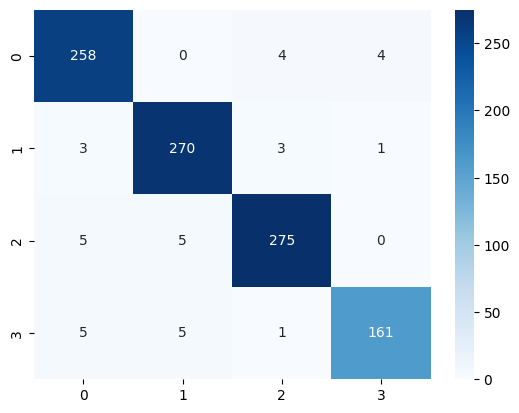

In [84]:
# Text Test 데이터셋에 label이 있어서 예측한 것과 비교용으로 시각화 하였습니다.
# 시험에서는 label이 없기 때문에 확인할 수 없습니다.
# Text RandomForestClassifier 모델

from sklearn.metrics import confusion_matrix

text_cm = confusion_matrix(text_y_test, text_rfc_y_pred)
sns.heatmap(data=text_cm, annot=True, fmt='d', cmap='Blues')
plt.show()

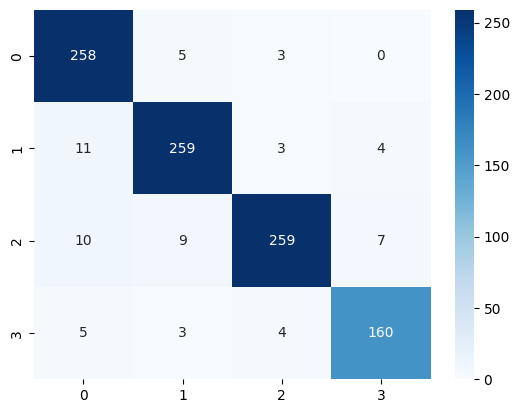

In [85]:
# Text 딥러닝 모델
text_cm = confusion_matrix(text_y_test, text_model_y_pred)
sns.heatmap(data=text_cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [86]:
# Text RandomForestClassifier는 훈련 데이터셋 기준 0.908
# Text 딥러닝은 훈련 데이터셋 기준 0.873이 나와서 RandomForest 모델을 선택했습니다.
# Text 데이터 라벨이 4개인 분류인데 96% 성능이면 꽤 좋은거 같습니다.
# 위에서도 말씀드렸지만, Test Dataset에 라벨이 있기 때문에 예측값과 비교한 부분입니다.
# 시험에서는 불필요한 부분입니다.

text_df5['pred'] = text_rfc_y_pred
text_correct_count = sum(text_df5['label']==text_df5['pred'])
text_total_count = len(text_df5)
text_model_accuracy = text_correct_count/text_total_count
print(f'text_model_accuracy : {text_model_accuracy:.2f}')

text_model_accuracy : 0.96


In [87]:
# Text dataset에 예측한 값을 csv에 추가
text_df5['pred'] = text_rfc_y_pred
text_df5

,label,text,pred
0,3,i mentioned on facebook that i was struggling ...,3
1,2,bbc news amazon boss jeff bezos rejects claim...,2
2,0,microsoft why do i pay for word when it functi...,0
3,0,csgo matchmaking is so full of closet hacking ...,0
4,2,now the president is slapping americans in the...,2
...,...,...,...
995,3,toronto is the arts and culture capital of can...,3
996,3,this is actually a good move tot bring more vi...,3
997,1,today sucked so its time to drink wine n play ...,1
998,1,bought a fraction of microsoft today small wins,1


In [88]:
# Text dataset 라벨 인코딩 했던 것 원상태로
text_label_to_class = {0:'Negative', 1:'Positive', 2:'Neutral', 3:'Irrelevant'}
text_df5['label'] = text_df5['label'].map(text_label_to_class)
text_df5['pred'] = text_df5['pred'].map(text_label_to_class)
text_df5

,label,text,pred
0,Irrelevant,i mentioned on facebook that i was struggling ...,Irrelevant
1,Neutral,bbc news amazon boss jeff bezos rejects claim...,Neutral
2,Negative,microsoft why do i pay for word when it functi...,Negative
3,Negative,csgo matchmaking is so full of closet hacking ...,Negative
4,Neutral,now the president is slapping americans in the...,Neutral
...,...,...,...
995,Irrelevant,toronto is the arts and culture capital of can...,Irrelevant
996,Irrelevant,this is actually a good move tot bring more vi...,Irrelevant
997,Positive,today sucked so its time to drink wine n play ...,Positive
998,Positive,bought a fraction of microsoft today small wins,Positive


In [89]:
# Text Test 데이터셋.csv 저장 및 불러와서 확인
text_df5.to_csv('01012345678_2.csv', index=False, encoding='utf-8')
text_df6 = pd.read_csv('01012345678_2.csv')
text_df6

,label,text,pred
0,Irrelevant,i mentioned on facebook that i was struggling ...,Irrelevant
1,Neutral,bbc news amazon boss jeff bezos rejects claim...,Neutral
2,Negative,microsoft why do i pay for word when it functi...,Negative
3,Negative,csgo matchmaking is so full of closet hacking ...,Negative
4,Neutral,now the president is slapping americans in the...,Neutral
...,...,...,...
995,Irrelevant,toronto is the arts and culture capital of can...,Irrelevant
996,Irrelevant,this is actually a good move tot bring more vi...,Irrelevant
997,Positive,today sucked so its time to drink wine n play ...,Positive
998,Positive,bought a fraction of microsoft today small wins,Positive


In [91]:
# Text RandomForestClassifier 모델 저장
joblib.dump(rfc, '01012345678_2.joblib')

['01012345678_2.joblib']

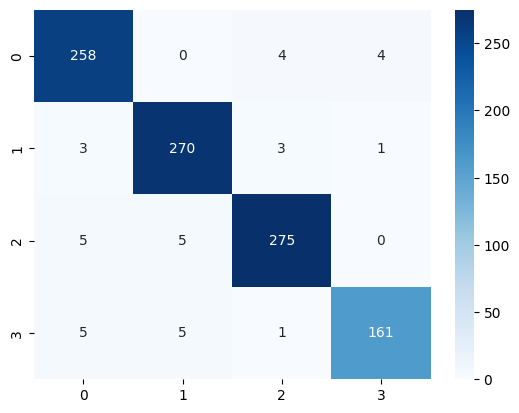

In [92]:
# Text 모델 저장 잘 되었는지 불러와서 성능 확인
text_load_model = joblib.load('01012345678_2.joblib')
text_load_y_pred = text_load_model.predict(text_x_test_v)
text_cm = confusion_matrix(text_y_test, text_load_y_pred)
sns.heatmap(data=text_cm, annot=True, fmt='d', cmap='Blues')
plt.show()